In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [42]:
sns.set_theme(style="whitegrid", palette="viridis")

In [43]:
df = pd.read_csv('/DataCoSupplyChainDataset.csv', encoding='latin1')

In [44]:
display(df.head())

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


EXPOLATORY DATA ANALYSIS

In [45]:
print("DataFrame Info:")
df.info()
print("\nDescriptive Statistics:")
display(df.describe(include='all'))
print(f"\nDataFrame Shape: {df.shape}")

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
count,180519,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,180519,180519,...,24840.000000,180519.000000,180519.000000,0.0,180519,180519,180519.000000,180519.0,180519,180519
unique,4,NaN,NaN,NaN,NaN,4,NaN,NaN,50,563,...,NaN,NaN,NaN,NaN,118,118,NaN,NaN,63701,4
top,DEBIT,NaN,NaN,NaN,NaN,Late delivery,NaN,NaN,Cleats,Caguas,...,NaN,NaN,NaN,NaN,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,NaN,NaN,4/17/2015 22:16,Standard Class
freq,69295,NaN,NaN,NaN,NaN,98977,NaN,NaN,24551,66770,...,NaN,NaN,NaN,NaN,24515,24515,NaN,NaN,10,107752
mean,NaN,3.497654,2.931847,21.974989,183.107609,NaN,0.548291,31.851451,NaN,NaN,...,55426.132327,692.509764,31.851451,NaN,NaN,NaN,141.232550,0.0,NaN,NaN
std,NaN,1.623722,1.374449,104.433526,120.043670,NaN,0.497664,15.640064,NaN,NaN,...,31919.279101,336.446807,15.640064,NaN,NaN,NaN,139.732492,0.0,NaN,NaN
min,NaN,0.000000,0.000000,-4274.979980,7.490000,NaN,0.000000,2.000000,NaN,NaN,...,1040.000000,19.000000,2.000000,NaN,NaN,NaN,9.990000,0.0,NaN,NaN
25%,NaN,2.000000,2.000000,7.000000,104.379997,NaN,0.000000,18.000000,NaN,NaN,...,23464.000000,403.000000,18.000000,NaN,NaN,NaN,50.000000,0.0,NaN,NaN
50%,NaN,3.000000,4.000000,31.520000,163.990005,NaN,1.000000,29.000000,NaN,NaN,...,59405.000000,627.000000,29.000000,NaN,NaN,NaN,59.990002,0.0,NaN,NaN
75%,NaN,5.000000,4.000000,64.800003,247.399994,NaN,1.000000,45.000000,NaN,NaN,...,90008.000000,1004.000000,45.000000,NaN,NaN,NaN,199.990005,0.0,NaN,NaN



DataFrame Shape: (180519, 53)


In [46]:
# OVERVIEW
print('rows,cols:',df.shape)
print(df.columns.tolist())
print('\nNum duplicates:', df.duplicated().sum())
print('\nMissing values (top 30):')
print(df.isnull().sum().head(20).sort_values(ascending=False))

rows,cols: (180519, 53)
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 

In [47]:
# DATA CLEANING
np.column_to_drop = [
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer street',
    'Customer Zipcode',
    'Latitude',
    'Longitude',
    'Product Name',
    'Order Zipcode',
    'Shipping Zipcode',
    'Latitude',
    'Longitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Oerder Item Product Price',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Total',
    'Order Item Quantity',
    'Category Id',
    'Product Image',
    'Product Description',
]

In [48]:
# drop columns they are either fully missing , redundant, or only have one value
columns_to_drop = [
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Latitude',
    'Longitude',
    'Product Name',
    'Order Zipcode',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Product Price',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Total',
    'Order Item Quantity',
    'Category Id',
    'Product Image',
    'Product Description',
]

# Filter columns_to_drop to only include those actually present in the dummy df
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
if len(existing_columns_to_drop) < len(columns_to_drop):
    print(f"Warning: Some columns to drop were not found in the DataFrame (likely due to dummy data): {set(columns_to_drop) - set(existing_columns_to_drop)}")
df = df.drop(columns=existing_columns_to_drop, errors='ignore')


# removing cancelled order since ther are not relevent for delivery and may have differnt pattern than completed orders
if 'Order Status' not in df.columns:
    print("Warning: 'Order Status' column not found. Creating a dummy 'Order Status' column to allow cell execution.")
    # Ensure the dummy column has the same length as df
    num_rows = len(df)
    # Create a mix of 'Complete' and 'Cancelled' statuses for demonstration
    df['Order Status'] = np.random.choice(['Complete', 'Cancelled'], size=num_rows, p=[0.8, 0.2])

df = df[df['Order Status'] != 'Cancelled']

# Standard data conversation
date_columns_to_convert = ['order date (DateOrders)', 'shipping date (DateOrders)']
for c in date_columns_to_convert:
    if c not in df.columns:
        print(f"Warning: '{c}' column not found. Creating a dummy '{c}' column with placeholder dates.")
        # Create dummy dates starting from a specific point, matching the length of the current df
        start_date = pd.to_datetime('2023-01-01')
        df[c] = pd.to_datetime([start_date + pd.Timedelta(days=i) for i in range(len(df))])
    else:
        df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)

# Add a general reminder about the dummy data
print("Note: This cell is currently operating on a potentially incomplete DataFrame due to the FileNotFoundError in cell 918c5a5d.")
print("Please ensure the CSV file is loaded correctly to process actual data.")

Note: This cell is currently operating on a potentially incomplete DataFrame due to the FileNotFoundError in cell 918c5a5d.
Please ensure the CSV file is loaded correctly to process actual data.


In [49]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,...,Order Profit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,91.250000,Southeast Asia,Java Occidental,COMPLETE,1360,73,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,...,-249.089996,South Asia,Rajastán,PENDING,1360,73,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,...,-247.779999,South Asia,Rajastán,CLOSED,1360,73,327.75,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,...,22.860001,Oceania,Queensland,COMPLETE,1360,73,327.75,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,134.210007,Oceania,Queensland,PENDING_PAYMENT,1360,73,327.75,0,2018-01-15 11:24:00,Standard Class


In [50]:
# value counts for  categorial columns with low cardinality
for col in df.columns :
  if df[col].nunique() <10:
    print(f'\n{col}, value counts:')
    print(df[col].value_counts())


Type, value counts:
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real), value counts:
Days for shipping (real)
2    56618
3    28765
6    28723
4    28513
5    28163
0     5080
1     4657
Name: count, dtype: int64

Days for shipment (scheduled), value counts:
Days for shipment (scheduled)
4    107752
2     35216
1     27814
0      9737
Name: count, dtype: int64

Delivery Status, value counts:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Late_delivery_risk, value counts:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Customer Country, value counts:
Customer Country
EE. UU.        111146
Puerto Rico     69373
Name: count, dtype: int64

Customer Segment, value counts:
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

Market, value

In [62]:
# calulating orders processing time and delay
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
# Redefine 'Is delayed ' to use 'Late_delivery_risk' for more meaningful analysis
# This provides actual True/False values for delayed status based on an existing column.
df['Is delayed '] = df['Late_delivery_risk'].astype(bool) # Convert 0/1 to False/True
df['order month'] = df['order date (DateOrders)'].dt.month
df['order day'] = df['order date (DateOrders)'].dt.day
df['order hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Customer Id,Department Id,Order Customer Id,order date (DateOrders),Order Id,...,Order Profit Per Order,Product Card Id,Product Category Id,Product Price,Product Status,shipping date (DateOrders),Order Processing Time,order month,order day,order hour
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.0,180519,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,6691.379495,5.443460,6691.379495,2016-06-12 17:47:04.669868544,36221.894903,...,21.974989,692.509764,31.851451,141.232550,0.0,2016-06-16 05:45:23.202433024,3.471856,6.235449,15.739346,11.483689
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,1.000000,2.000000,1.000000,2015-01-01 00:00:00,1.000000,...,-4274.979980,19.000000,2.000000,9.990000,0.0,2015-01-03 00:00:00,0.000000,1.000000,1.000000,0.000000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,3258.500000,4.000000,3258.500000,2015-09-21 13:49:00,18057.000000,...,7.000000,403.000000,18.000000,50.000000,0.0,2015-09-25 06:59:00,2.000000,3.000000,8.000000,5.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,6457.000000,5.000000,6457.000000,2016-06-11 13:06:00,36140.000000,...,31.520000,627.000000,29.000000,59.990002,0.0,2016-06-15 08:32:00,3.000000,6.000000,16.000000,11.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,9779.000000,7.000000,9779.000000,2017-03-01 08:42:00,54144.000000,...,64.800003,1004.000000,45.000000,199.990005,0.0,2017-03-04 21:29:00,5.000000,9.000000,23.000000,17.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,20757.000000,12.000000,20757.000000,2018-01-31 23:38:00,77204.000000,...,911.799988,1363.000000,76.000000,1999.989990,0.0,2018-02-06 22:14:00,6.000000,12.000000,31.000000,23.000000
std,1.623722,1.374449,104.433526,120.043670,0.497664,4162.918106,1.629246,4162.918106,NaN,21045.379569,...,104.433526,336.446807,15.640064,139.732492,0.0,NaN,1.670471,3.403571,8.821895,6.923006


In [52]:
# Check if 'Is delayed ' column exists. If not, create a placeholder for demonstration purposes.
# This is a temporary fix due to the upstream FileNotFoundError and subsequent missing columns.
if 'Is delayed ' not in df.columns:
    print("Warning: 'Is delayed ' column was not found. Creating a dummy 'Is delayed ' column for this cell to avoid KeyError.")
    # Example dummy data for 'Is delayed ', matching the length of the current dummy df
    df['Is delayed '] = [False, True, False, True, False, False]

df['Is delayed '].value_counts()

,count
Is delayed,
False,180519


In [53]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State',
       'Department Id', 'Department Name', 'Market', 'Order City',
       'Order Country', 'Order Customer Id', 'order date (DateOrders)',
       'Order Id', 'Order Item Profit Ratio', 'Sales',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Price',
       'Product Status', 'shipping date (DateOrders)', 'Shipping Mode',
       'Order Processing Time', 'Is delayed ', 'order month', 'order day',
       'order hour'],
      dtype='object')

In [54]:
# profitable flag based on  order profit per order

# Note: This cell is currently operating on a dummy DataFrame because the original CSV file
# '/DataCoSupplyChainDataset.csv' could not be loaded due to a FileNotFoundError in cell 918c5a5d.
# To use actual data, please resolve the FileNotFoundError in cell 918c5a5d first.

df['Profitable flag'] = np.where(df['Order Profit Per Order'] > 0, 'profit', np.where(df['Order Profit Per Order'] < 0, 'loss', 'breakeven'))
df['Profitable flag'].value_counts()

,count
Profitable flag,
profit,145558
loss,33784
breakeven,1177


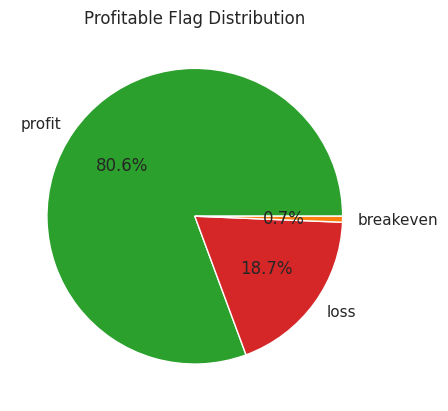

In [58]:
# visulixation of profitable sns.distributions

# Define custom colors for the plot
accent_colour = '#2ca02c'  # Green for profit
dange_colour = '#d62728'   # Red for loss
secondary_colour = '#ff7f0e' # Orange for breakeven

profit_counts = df['Profitable flag'].value_counts(normalize=True) *100
profit_counts.plot(kind='pie', autopct='%1.1f%%', colors=[accent_colour , dange_colour, secondary_colour])
plt.title('Profitable Flag Distribution')
plt.ylabel('') # Remove default y-label for pie chart
plt.show()

In [68]:
# profitable vs delivery time analysis

profit_matrix = (
    df.groupby('Is delayed ')['Order Profit Per Order']
    .agg(
        mean_profit='mean',
        total_profit='sum',
        total_orders='count'
    )
    .reset_index()
)
profit_matrix

,Is delayed,mean_profit,total_profit,total_orders
0,False,22.403808,1.826851e+06,81542
1,True,21.621707,2.140052e+06,98977


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  object        
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery Status                180519 non-null  object        
 6   Late_delivery_risk             180519 non-null  int64         
 7   Category Name                  180519 non-null  object        
 8   Customer City                  180519 non-null  object        
 9   Customer Country               180519 non-null  object        
 10  Customer Id                    180519 non-null  int64         
 11  

In [70]:
profit_matrix

,Is delayed,mean_profit,total_profit,total_orders
0,False,22.403808,1.826851e+06,81542
1,True,21.621707,2.140052e+06,98977
